# In-place Y-basis preparation and readout

Prepare a logical |Y⟩ in place, keep it for a few rounds, and read it out in place, with the
construction of Gidney, *Inplace Access to the Surface Code Y Basis*
([arXiv:2302.07395](https://arxiv.org/abs/2302.07395)).
The transition round is `make_y_transition_chunk` in
[`y_transition_round.py`](https://github.com/John-YuehanZhang/CircLS/blob/main/lightstim/qec_code/surface_code/rotated/y_transition_round.py)
and the degenerate patch is in
[`y_boundary_patch.py`](https://github.com/John-YuehanZhang/CircLS/blob/main/lightstim/qec_code/surface_code/rotated/y_boundary_patch.py);
both are ports of Gidney's published code (CC-BY-4.0, see `VENDORED.md`).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pymatching

from lightstim.ir.qec_system import QECSystem
from lightstim.ir.tracker import SyndromeTracker
from lightstim.ir.builder import CircuitBuilder
from lightstim.noise.config import NoiseConfig
from lightstim.qec_code.surface_code.rotated import RotatedSurfaceCode
from lightstim.qec_code.surface_code.rotated.SE_block import RotatedSurfaceCodeExtractionBlock
from lightstim.qec_code.surface_code.rotated.y_boundary_patch import make_degenerate_y_boundary_patch
from lightstim.qec_code.surface_code.rotated.y_transition_round import make_y_transition_chunk

import stim
print("stim", stim.__version__, "| pymatching", pymatching.__version__)


stim 1.16.0 | pymatching 2.4.0


## 1. Preparation, memory rounds, readout

* **Preparation.**  Start from the degenerate patch (d²−1 data qubits, no logical qubit), reset the
  data qubits in a mixed X/Z pattern, run `1 + rb` time-reversed rounds, grow to the full patch
  and apply the transition round with `direction='init'`, which prepares Y_L.
* **Memory.**  `memory_rounds` ordinary rounds (default `d`, as in Gidney's reference circuits).
* **Readout.**  Switch back to the degenerate patch's checks and apply the transition round with
  `direction='measure'`, which measures Y_L; `1 + rb` more rounds and a mixed-basis data readout
  close the detectors.

The rounds next to the transition use Gidney's interaction order (`'gidney'` and its time reverse
`'gidney_reversed'`); with another order the transition loses distance.

**Padding rounds.**  `rb = max(d//2, d − 3)`; Gidney's reference circuits use `d//2`.  The two agree at
d = 3, 5.  At d = 7 the extra round is what stim's hyperedge-aware search
(`search_for_undetectable_logical_errors`) needs to find no logical error below 7 faults: with `rb = 3` it
finds one with 6 faults, on Gidney's published circuit as well as here.  The compiler's default
(`SequentialPPMExperiment`, `y_pad_rounds=None`) is still `d//2`; Example 3 passes the padding explicitly.

**Detectors and observables are not written by hand.**  Every `DETECTOR` and `OBSERVABLE_INCLUDE` below is
derived by the syndrome tracker in
[`lightstim/ir/tracker.py`](https://github.com/John-YuehanZhang/CircLS/blob/main/lightstim/ir/tracker.py).
The cell after `y_prep_readout` shows that the transition chunk itself contains no annotation.

In [2]:
def y_prep_readout(d, memory_rounds=None, transpose=False):
    """Gidney Y memory; transpose=True builds the X_horizontal orientation (both patches reflected across y = x)."""
    r = d if memory_rounds is None else memory_rounds
    rb = max(d // 2, d - 3)                 # padding rounds on the degenerate patch, see Section 1
    system = QECSystem()
    degen = make_degenerate_y_boundary_patch(d)
    if transpose:
        degen.transpose_coords()
    gp_degen = system.add_patch(degen, name="P", offset=(0, 0))
    degen_uids = set(gp_degen._registered_stabilizer_uids)
    tracker = SyndromeTracker(num_qubits=system.num_qubits, expected_num_logicals=0)
    builder = CircuitBuilder(tracker=tracker, system_config=system, if_detector=True)
    system.register_tracker(tracker)
    system.register_builder(builder)
    builder.write_coordinates()              # QUBIT_COORDS for every qubit (annotation only: drawing, Crumble)

    def mixed_basis():                          # Z below the anti-diagonal, X above
        out = {}
        for q in system.data_indices:
            x, y = system.qubit_coords[q]
            out[q] = "Z" if (x - 1) // 2 + (y - 1) // 2 < d else "X"
        return out

    # preparation
    builder.initialize(init_dict=mixed_basis(), n=system.num_qubits)
    ch_rev = RotatedSurfaceCodeExtractionBlock(system, scheduling="gidney_reversed").circuit
    builder.apply_syndrome_extraction(circuit_chunk=ch_rev, rounds=1)
    builder.apply_syndrome_extraction(circuit_chunk=ch_rev, rounds=rb)
    full = RotatedSurfaceCode(distance=d)
    if transpose:
        full.transpose_coords()
    system.grow_patch("P", full, offset=(0, 0))
    builder.apply_relay_chunk(make_y_transition_chunk(system, "P", gp_degen, direction="init"))
    n = tracker.num_qubits
    y_logical = np.zeros(2 * n, dtype=np.uint8)            # Y_L = X_L * Z_L as a symplectic vector
    for rec in [x for x in system.logical_ops if x.get("patch_name") == "P"]:
        for q, pauli in rec["pauli"].items():
            if pauli in ("X", "Y"):
                y_logical[q] ^= 1
            if pauli in ("Z", "Y"):
                y_logical[n + q] ^= 1
    tracker.declare_logical(y_logical)

    # memory
    ch_fwd = RotatedSurfaceCodeExtractionBlock(system, scheduling="gidney").circuit
    if r:
        builder.apply_syndrome_extraction(circuit_chunk=ch_fwd, rounds=r)

    # readout
    system.active_stabilizer_indices.clear()
    system.active_stabilizer_indices.update(degen_uids)
    builder.apply_relay_chunk(make_y_transition_chunk(system, "P", gp_degen, direction="measure"))
    ch_deg = RotatedSurfaceCodeExtractionBlock(system, scheduling="gidney").circuit
    builder.apply_syndrome_extraction(circuit_chunk=ch_deg, rounds=rb)
    builder.apply_syndrome_extraction(circuit_chunk=ch_deg, rounds=1)
    final = {q: b for q, b in mixed_basis().items() if q in gp_degen.data_indices}
    builder.apply_data_readout(final_measurements=final)
    return builder


In [3]:
# The transition chunk as handed to apply_relay_chunk: gates and measurements only.
_sys = QECSystem()
_gp = _sys.add_patch(make_degenerate_y_boundary_patch(3), name="P", offset=(0, 0))
_sys.grow_patch("P", RotatedSurfaceCode(distance=3), offset=(0, 0))
chunk = make_y_transition_chunk(_sys, "P", _gp, direction="init")
names = sorted({inst.name for inst in chunk})
print("instructions in the transition chunk:", names)
print("DETECTOR / OBSERVABLE_INCLUDE lines in the chunk:", chunk.num_detectors, "/", chunk.num_observables)

instructions in the transition chunk: ['CX', 'H', 'M', 'MX', 'R', 'RX', 'RY', 'SQRT_X', 'TICK', 'XCY']
DETECTOR / OBSERVABLE_INCLUDE lines in the chunk: 0 / 0


## 2. Example 1: X_vertical (Gidney's layout)

X boundaries top and bottom, Z boundaries left and right.  `circuit.diagram("detslice-with-ops-svg")`
draws the d = 3 circuit tick by tick: the gates of each tick and the detecting regions at that time,
through the preparation, the memory rounds and the readout.

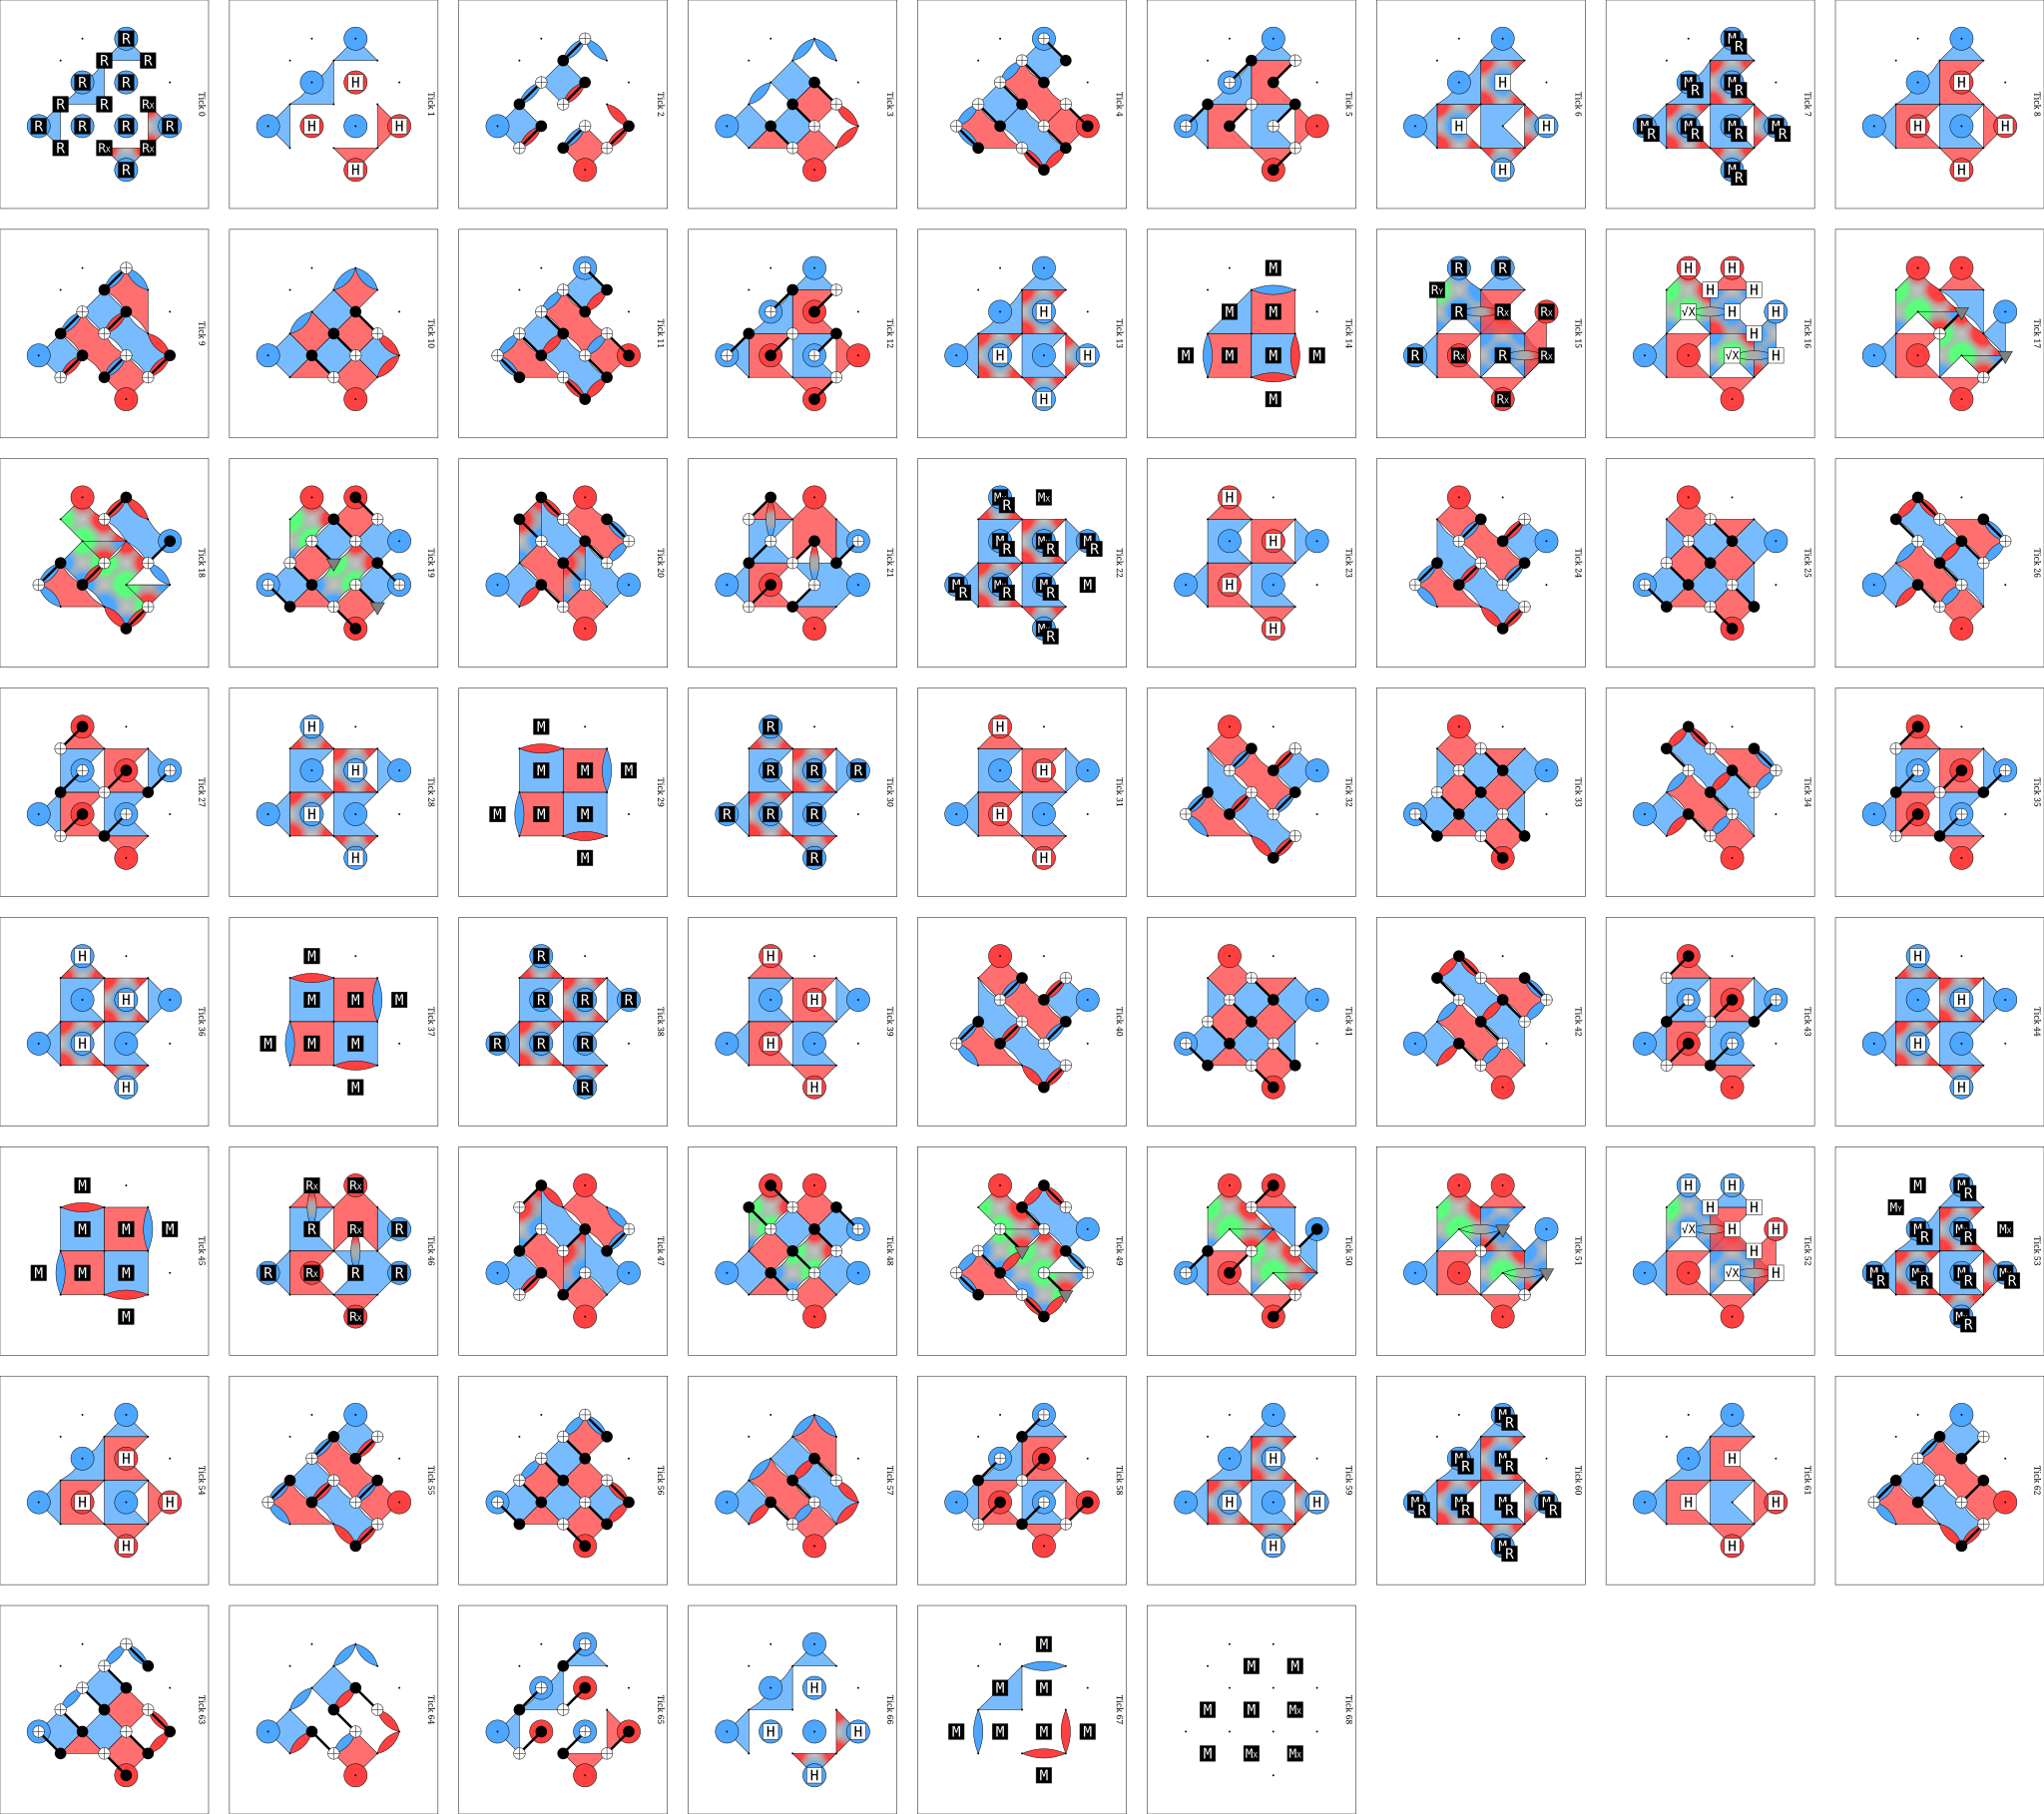

In [4]:
import stim
from IPython.display import SVG, display

builder = y_prep_readout(3)
display(SVG(str(builder.circuit.diagram("detslice-with-ops-svg"))))

## 3. Example 2: X_horizontal (the reflected construction)

X boundaries left and right.  This is the whole construction reflected across the line y = x: both
patches are built with `transpose_coords()` (`transpose=True` above), the transition chunk reads the
orientation off the patches, and the syndrome-extraction block reads the `'gidney'` schedule through the
same per-patch `transform_vector`.  The detectors and the observable are derived by the tracker as before.
Same drawing for the transposed d = 3 circuit.

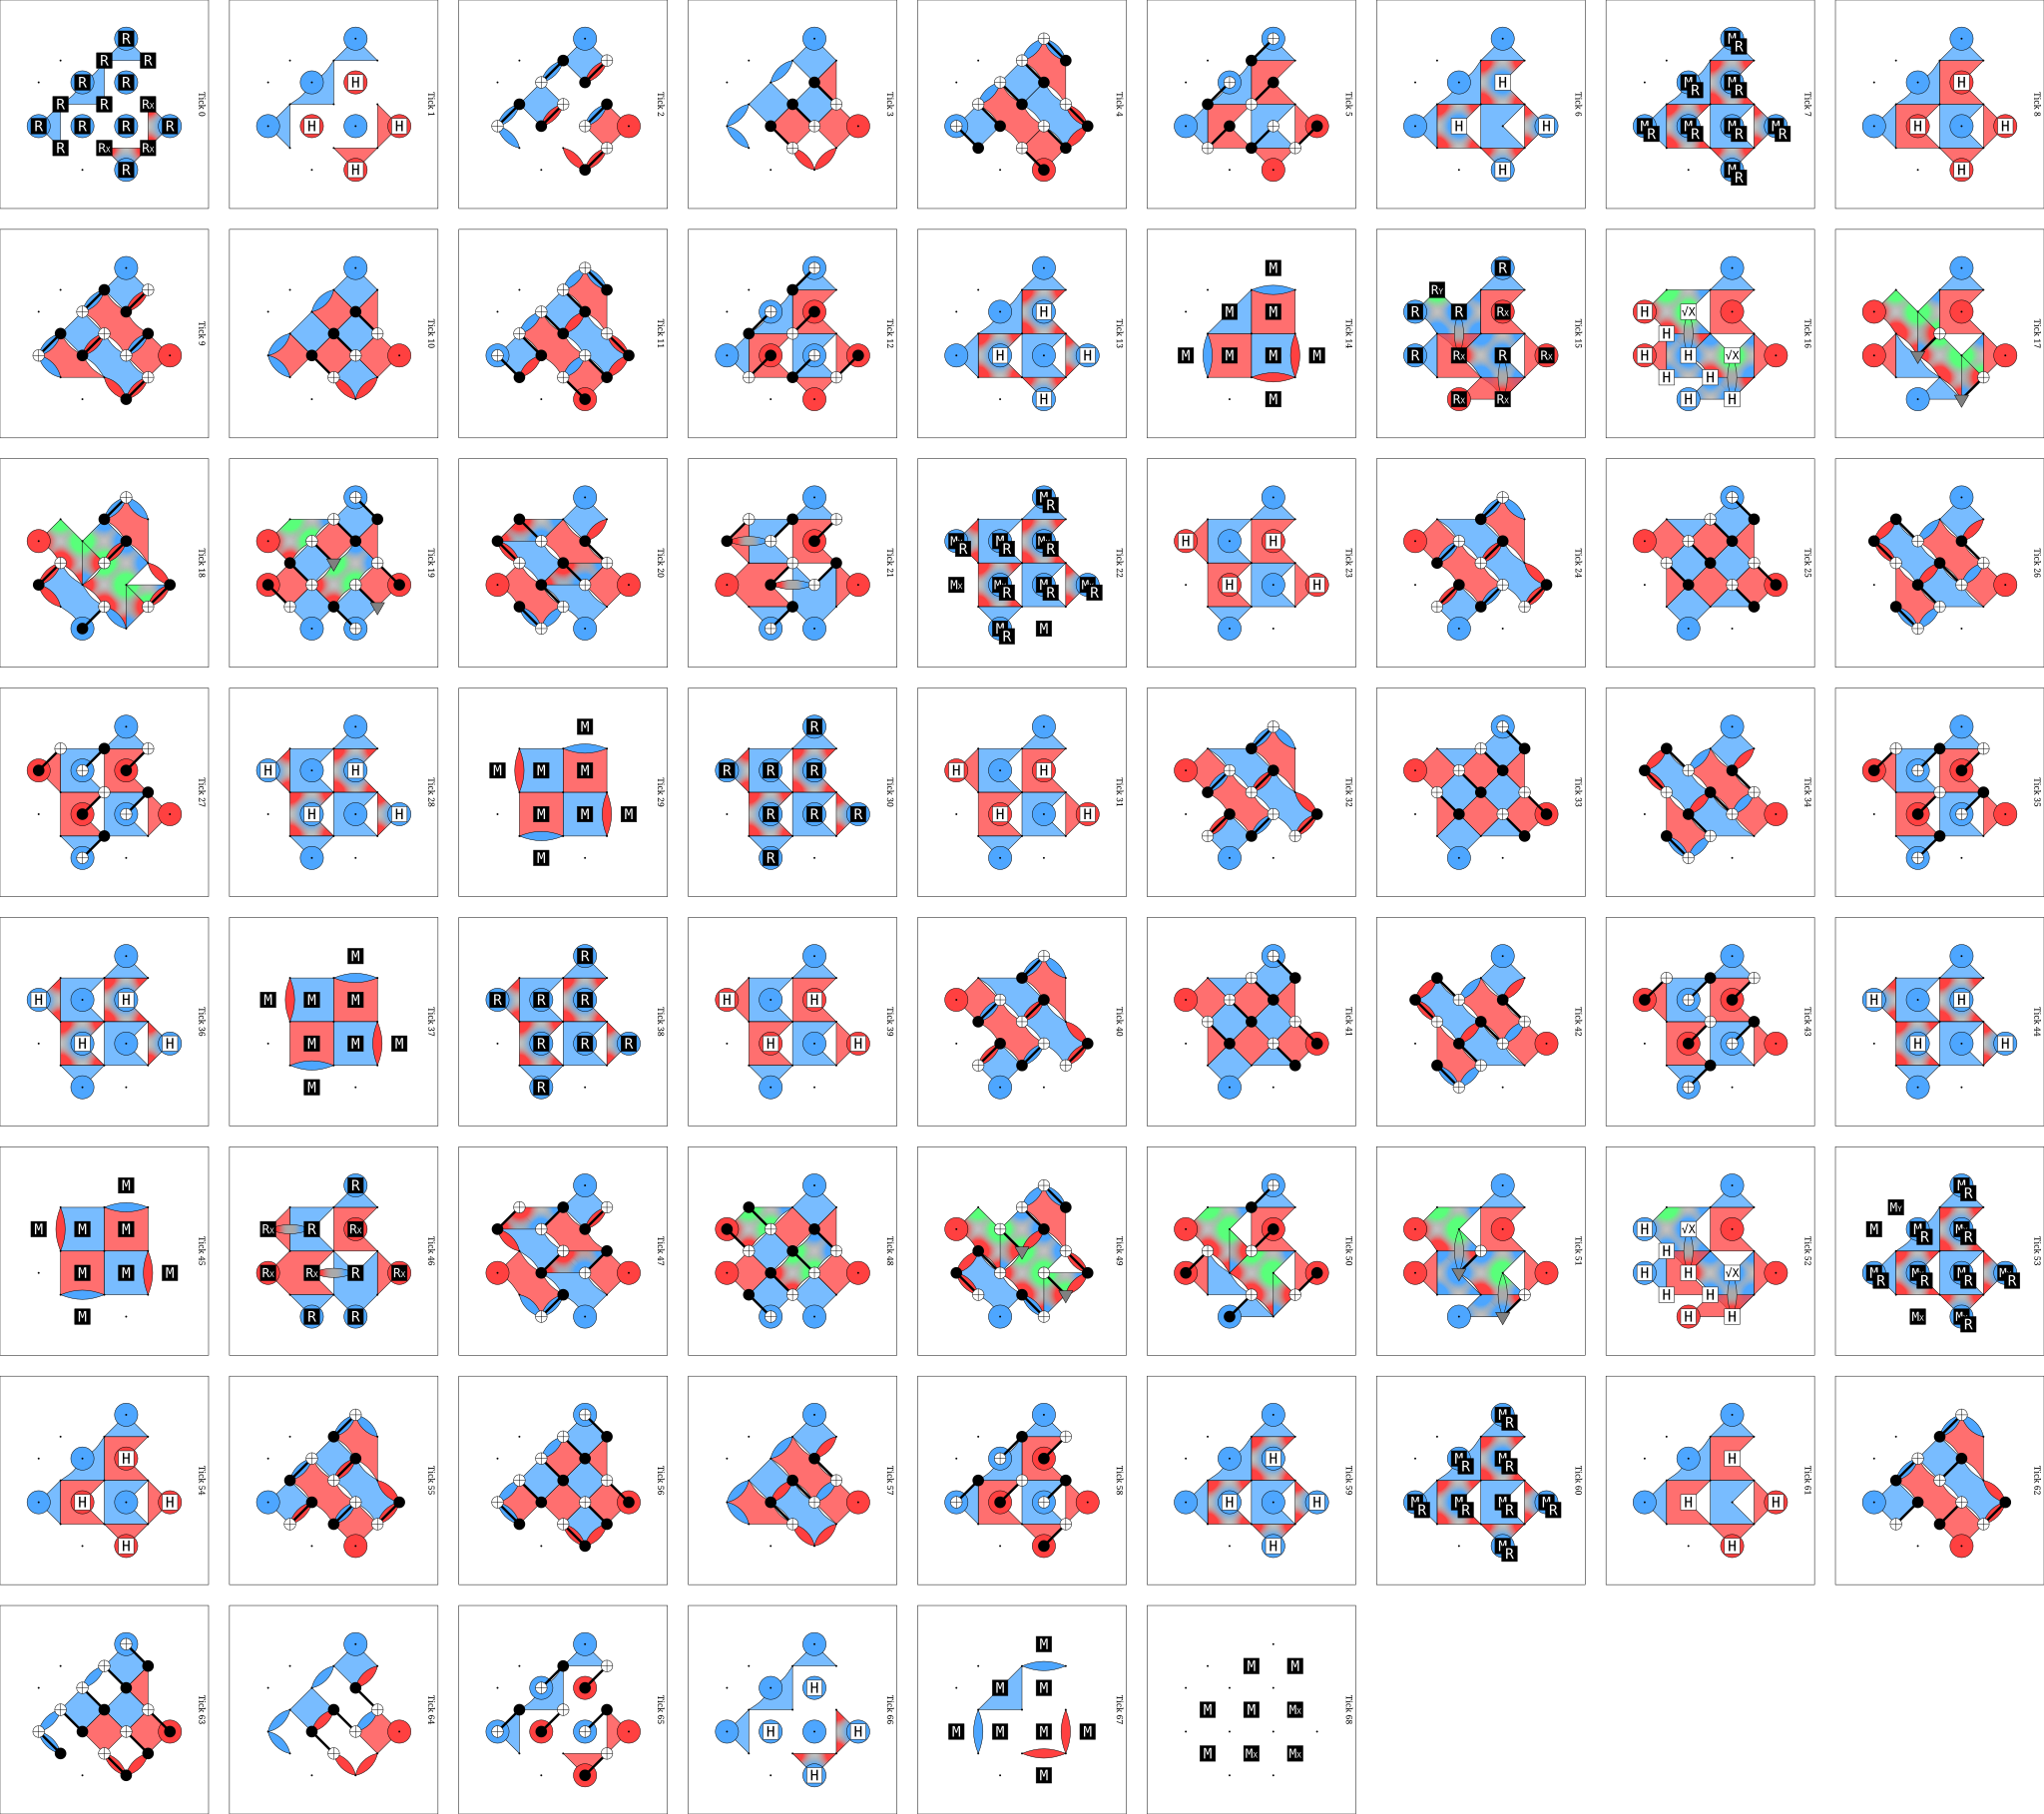

In [5]:
builder = y_prep_readout(3, transpose=True)
display(SVG(str(builder.circuit.diagram("detslice-with-ops-svg"))))

The orientation matters where the |Y⟩ patch meets other patches: Example 3 below compiles a joint
measurement with the ancilla in either orientation and placement, every detector and observable again
derived by the tracker.

## 4. Example 3: |Y⟩ birth followed by lattice surgery

A data patch `q0` prepared in |0⟩ and a |Y⟩ ancilla `y0` directly south of it, both `X_vertical`, sharing
a horizontal seam; one joint Z⊗Z measurement through that seam (the patches are merged for d rounds, then
split), then `y0` is read out in X and `q0` in Z: the π/4 (S-gate) teleportation gadget, written as a
two-patch PPM program for the CircLS compiler.  The program fixes the placement; the compiler births `y0`
with the construction of Section 1 (degenerate rounds and transition round, padding passed as
`y_pad_rounds = max(d//2, d − 3)`), builds the merge and split rounds, and the tracker derives every
detector and the observable.  Same drawing for the d = 3 circuit.

program : q0 |0>, y0 |Y> (X_vertical, directly south of q0, shared seam); PPM step Z(q0) Z(y0); readout q0 in Z, y0 in X
circuit : 42 qubits, 70 ticks, 129 detectors, 1 observable
p = 0   : silent=True, observable deterministic=True


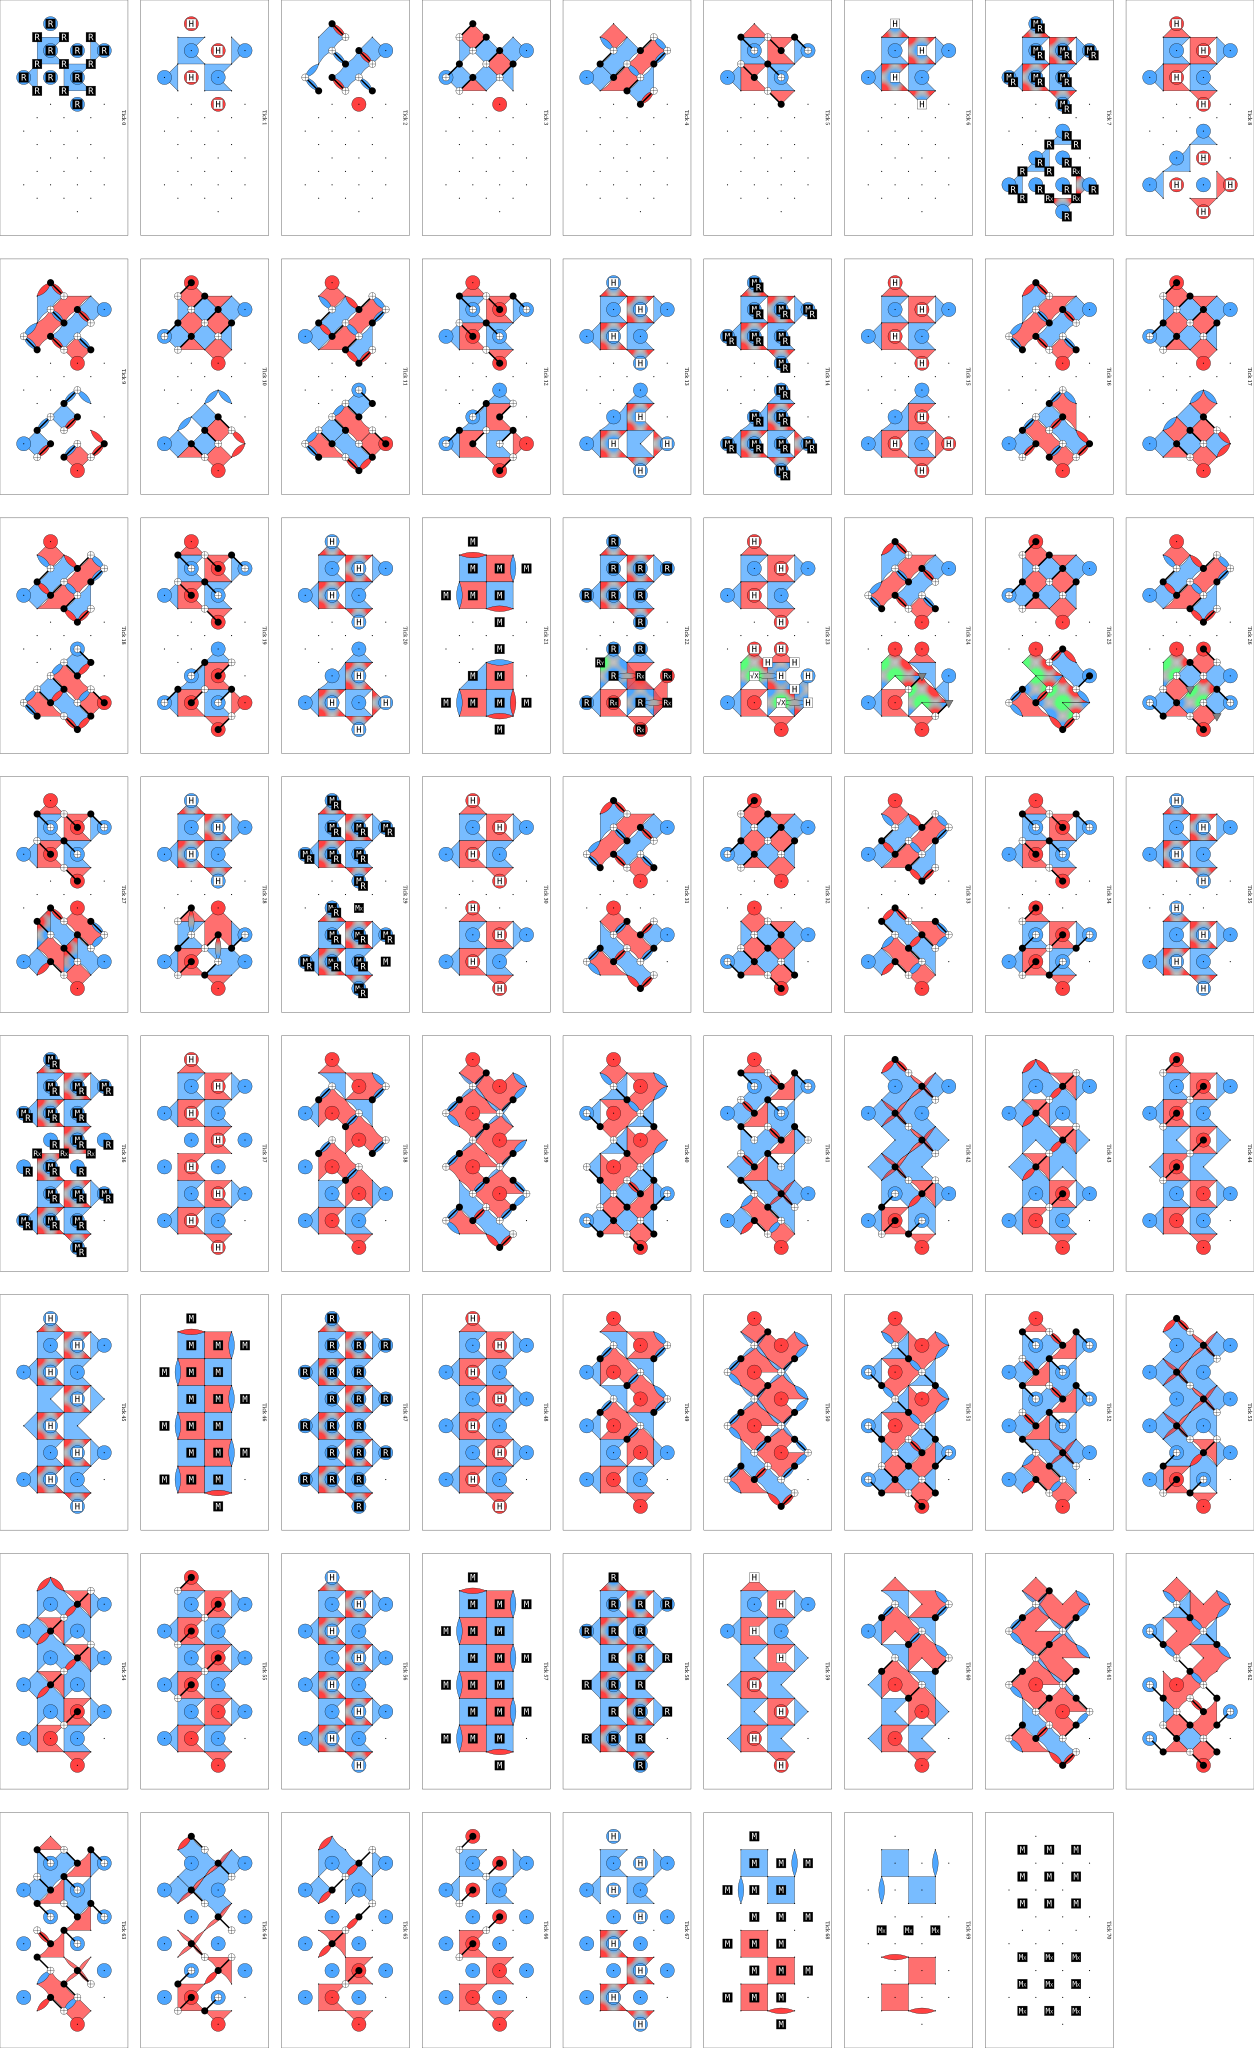

In [6]:
# |Y> ancilla + data patch, one Z (x) Z joint measurement: the pi/4 gadget as a PPM program
import contextlib, io
from circls.core.sequential_ppm_ls import PPMStep, SequentialPPMExperiment
from circls.core.routed_multi_patch_ls import PatchSpec, origin_of

def gadget(d, y_orientation, y_cell, noise=None):
    px = [PatchSpec("q0", origin_of(0, 0, d, seam=True), d, "X_vertical"),
          PatchSpec("y0", origin_of(*y_cell, d, seam=True), d, y_orientation)]
    exp = SequentialPPMExperiment(px, [PPMStep([("q0", "Z"), ("y0", "Z")])],
                                  initial_states={"q0": "Z", "y0": "Y"},
                                  final_measure_states={"q0": "Z", "y0": "X"},
                                  rounds=d, rounds_init=1, noise_params=noise,
                                  y_pad_rounds=max(d // 2, d - 3))     # Gidney's rb, as in Section 1
    with contextlib.redirect_stdout(io.StringIO()):
        return exp, exp.build()

exp, c = gadget(3, "X_vertical", (0, 1))
print("program : q0 |0>, y0 |Y> (X_vertical, directly south of q0, shared seam); PPM step Z(q0) Z(y0); readout q0 in Z, y0 in X")
print(f"circuit : {c.num_qubits} qubits, {c.num_ticks} ticks, {c.num_detectors} detectors, {c.num_observables} observable")
det, obs = c.compile_detector_sampler(seed=0).sample(512, separate_observables=True)
print(f"p = 0   : silent={not det.any()}, observable deterministic={not obs.any()}")
display(SVG(str(c.diagram("detslice-with-ops-svg"))))

In [7]:
# the same gadget with a routed corridor: the ancilla two cells east or south of q0 (the compiler routes the
# Z (x) Z corridor through the free cell between them), both ancilla orientations, d = 3 and 5
def logical_directions(exp, name):
    out = {}
    for rec in exp.system.logical_ops:
        if rec.get("patch_name") == name:
            xs = {exp.system.qubit_coords[q][0] for q in rec["pauli"]}
            out[rec["type"]] = "horizontal" if len(xs) > 1 else "vertical"
    return out

p = 1e-3
noise = NoiseConfig(p_1q=p, p_2q=p, p_meas=p, p_reset=p, p_idle=p)
for where, y_cell in (("two cells east of q0", (2, 0)), ("two cells south of q0", (0, 2))):
    for y_orientation in ("X_vertical", "X_horizontal"):
        for d in (3, 5):
            exp, c = gadget(d, y_orientation, y_cell)
            det, obs = c.compile_detector_sampler(seed=0).sample(512, separate_observables=True)
            dist = len(gadget(d, y_orientation, y_cell, noise)[1].shortest_graphlike_error(ignore_ungraphlike_errors=False))
            dirs = logical_directions(exp, "y0")
            print(f"ancilla {where:21s}, {y_orientation:12s} (X_L {dirs['X']}, Z_L {dirs['Z']}) d={d}: "
                  f"{c.num_detectors} detectors, {c.num_observables} observable, p=0 silent={not det.any()}, "
                  f"deterministic={not obs.any()}, graphlike distance={dist}")

ancilla two cells east of q0 , X_vertical   (X_L vertical, Z_L horizontal) d=3: 223 detectors, 1 observable, p=0 silent=True, deterministic=True, graphlike distance=3


ancilla two cells east of q0 , X_vertical   (X_L vertical, Z_L horizontal) d=5: 958 detectors, 1 observable, p=0 silent=True, deterministic=True, graphlike distance=5


ancilla two cells east of q0 , X_horizontal (X_L horizontal, Z_L vertical) d=3: 223 detectors, 1 observable, p=0 silent=True, deterministic=True, graphlike distance=3


ancilla two cells east of q0 , X_horizontal (X_L horizontal, Z_L vertical) d=5: 958 detectors, 1 observable, p=0 silent=True, deterministic=True, graphlike distance=5


ancilla two cells south of q0, X_vertical   (X_L vertical, Z_L horizontal) d=3: 161 detectors, 1 observable, p=0 silent=True, deterministic=True, graphlike distance=3


ancilla two cells south of q0, X_vertical   (X_L vertical, Z_L horizontal) d=5: 674 detectors, 1 observable, p=0 silent=True, deterministic=True, graphlike distance=5


ancilla two cells south of q0, X_horizontal (X_L horizontal, Z_L vertical) d=3: 221 detectors, 1 observable, p=0 silent=True, deterministic=True, graphlike distance=3


ancilla two cells south of q0, X_horizontal (X_L horizontal, Z_L vertical) d=5: 954 detectors, 1 observable, p=0 silent=True, deterministic=True, graphlike distance=5


## 5. Checks

With `memory_rounds = d` the circuit has 74 / 316 / 918 detectors at d = 3 / 5 / 7 and one observable, the
counts of Gidney's reference circuits with the same padding (rb = 1, 2, 4) (a check against the reference, not its source: see Section 1).  The same
checks are run for the `X_horizontal` orientation.  At p = 0 nothing fires, and under circuit-level depolarizing noise the
shortest graphlike logical error has length `d`, also when the state is read out right after
preparation (`memory_rounds = 0`).

In [8]:
p = 1e-3
noise = NoiseConfig(p_1q=p, p_2q=p, p_meas=p, p_reset=p, p_idle=p)

for label, transpose in (("X_vertical", False), ("X_horizontal", True)):
    for d in (3, 5, 7):
        for r in (d, 0):
            builder = y_prep_readout(d, memory_rounds=r, transpose=transpose)
            c = builder.circuit
            sample = c.compile_detector_sampler(seed=7).sample(256, append_observables=True)
            noisy = builder.build_noisy_circuit(noise_params=noise, noise_model="circuit_level")
            print(f"{label} d={d} memory_rounds={r}: {c.num_qubits} qubits, {c.num_detectors} detectors, "
                  f"{c.num_observables} observable, p=0 silent={not sample.any()}, "
                  f"graphlike distance={len(noisy.shortest_graphlike_error(ignore_ungraphlike_errors=False))}")


X_vertical d=3 memory_rounds=3: 19 qubits, 74 detectors, 1 observable, p=0 silent=True, graphlike distance=3
X_vertical d=3 memory_rounds=0: 19 qubits, 50 detectors, 1 observable, p=0 silent=True, graphlike distance=3


X_vertical d=5 memory_rounds=5: 53 qubits, 316 detectors, 1 observable, p=0 silent=True, graphlike distance=5


X_vertical d=5 memory_rounds=0: 53 qubits, 196 detectors, 1 observable, p=0 silent=True, graphlike distance=5


X_vertical d=7 memory_rounds=7: 103 qubits, 918 detectors, 1 observable, p=0 silent=True, graphlike distance=7


X_vertical d=7 memory_rounds=0: 103 qubits, 582 detectors, 1 observable, p=0 silent=True, graphlike distance=7
X_horizontal d=3 memory_rounds=3: 19 qubits, 74 detectors, 1 observable, p=0 silent=True, graphlike distance=3
X_horizontal d=3 memory_rounds=0: 19 qubits, 50 detectors, 1 observable, p=0 silent=True, graphlike distance=3


X_horizontal d=5 memory_rounds=5: 53 qubits, 316 detectors, 1 observable, p=0 silent=True, graphlike distance=5


X_horizontal d=5 memory_rounds=0: 53 qubits, 196 detectors, 1 observable, p=0 silent=True, graphlike distance=5


X_horizontal d=7 memory_rounds=7: 103 qubits, 918 detectors, 1 observable, p=0 silent=True, graphlike distance=7


X_horizontal d=7 memory_rounds=0: 103 qubits, 582 detectors, 1 observable, p=0 silent=True, graphlike distance=7


## 6. Logical error rate

Sample the noisy circuit and decode with PyMatching: Example 1 and Example 2 (the isolated Y memory in the two
orientations) and Example 3 (|Y⟩ birth, Z⊗Z merge with the data patch, readout).  Examples 1 and 2 give the same
counts because their circuits are the same instruction stream on the same qubit indices (the reflection only
changes coordinates and the order of the DETECTOR declarations) and the sampler is seeded.  Seeded samples are
not stable across stim versions; the first cell prints the versions used.

In [9]:
def logical_error_rate(circuit, shots, seed=0):
    """Sample the noisy circuit and decode with PyMatching; returns (errors, shots)."""
    dem = circuit.detector_error_model(decompose_errors=True)
    matcher = pymatching.Matching.from_detector_error_model(dem)
    det, obs = circuit.compile_detector_sampler(seed=seed).sample(shots, separate_observables=True)
    errors = int(np.any(matcher.decode_batch(det) != obs, axis=1).sum())
    return errors, shots

p = 2e-3
noise = NoiseConfig(p_1q=p, p_2q=p, p_meas=p, p_reset=p, p_idle=p)
for label, transpose in (("Example 1", False), ("Example 2", True)):
    for d in (3, 5, 7):
        noisy = y_prep_readout(d, transpose=transpose).build_noisy_circuit(noise_params=noise, noise_model="circuit_level")
        errors, shots = logical_error_rate(noisy, shots=200_000)
        print(f"{label} p={p:g} d={d}: LER = {errors / shots:.2e} ({errors}/{shots})")

# Example 3: |Y> birth followed by the Z (x) Z lattice-surgery merge with the data patch (ancilla directly south of q0, shared seam)
for d in (3, 5, 7):
    noisy = gadget(d, "X_vertical", (0, 1), noise)[1]
    errors, shots = logical_error_rate(noisy, shots=200_000)
    print(f"Example 3 p={p:g} d={d}: LER = {errors / shots:.2e} ({errors}/{shots})")


Example 1 p=0.002 d=3: LER = 1.14e-02 (2280/200000)


Example 1 p=0.002 d=5: LER = 3.91e-03 (781/200000)


Example 1 p=0.002 d=7: LER = 1.18e-03 (235/200000)


Example 2 p=0.002 d=3: LER = 1.14e-02 (2280/200000)


Example 2 p=0.002 d=5: LER = 3.91e-03 (781/200000)


Example 2 p=0.002 d=7: LER = 1.18e-03 (235/200000)


Example 3 p=0.002 d=3: LER = 5.07e-03 (1013/200000)


Example 3 p=0.002 d=5: LER = 1.20e-03 (239/200000)


Example 3 p=0.002 d=7: LER = 2.30e-04 (46/200000)
